In [4]:
#Setup and Data Inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define the local file path
file_path = r"C:\Users\vidhe\Downloads\retail_sales_dataset.csv"

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/retail_sales_dataset.csv")

# Initial inspection
print("Dataset Shape:", df.shape)
print("\n--- Column Data Types ---")
print(df.dtypes)
print("\n--- Null Value Check ---")
print(df.isnull().sum())

# Convert 'Date' to datetime format for time series analysis
df['Date'] = pd.to_datetime(df['Date'])

Dataset Shape: (1000, 9)

--- Column Data Types ---
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

--- Null Value Check ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
# Descriptive Statistics
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

desc_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Std Dev': df[numerical_cols].std()
})
print("--- Descriptive Statistics ---")
display(desc_stats)

--- Descriptive Statistics ---


,Mean,Median,Mode,Std Dev
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


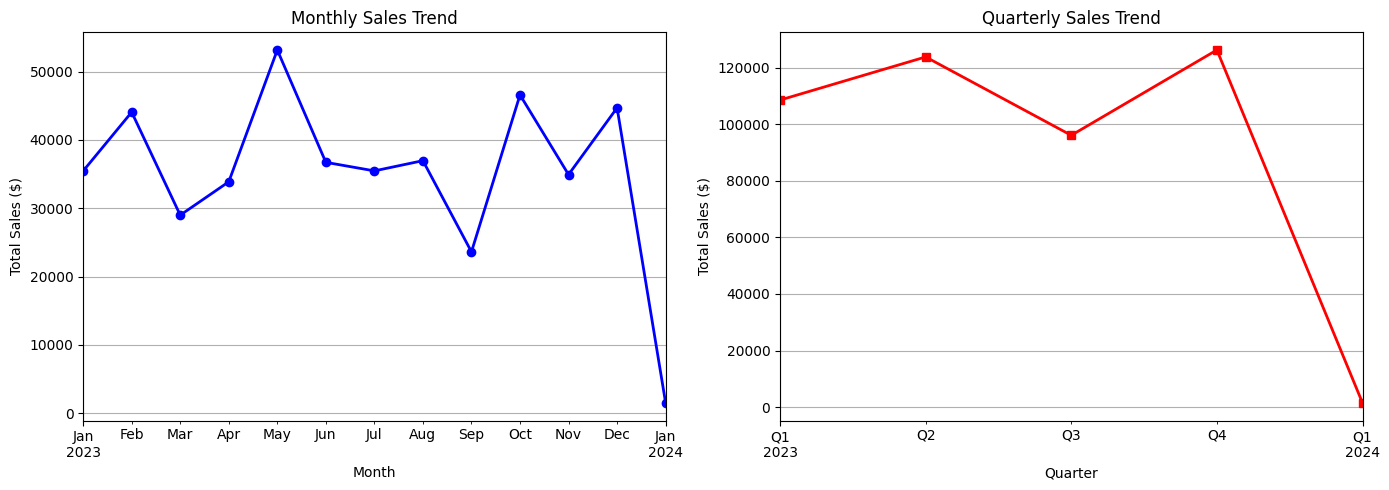

In [6]:
# Time Series Analysis
df.set_index('Date', inplace=True)

# Resample sales data to Monthly and Quarterly totals
monthly_sales = df['Total Amount'].resample('M').sum()
quarterly_sales = df['Total Amount'].resample('Q').sum()

# Plot trends
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)

plt.subplot(1, 2, 2)
quarterly_sales.plot(kind='line', marker='s', color='r', linewidth=2)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Reset index to restore 'Date' as a regular column
df.reset_index(inplace=True)

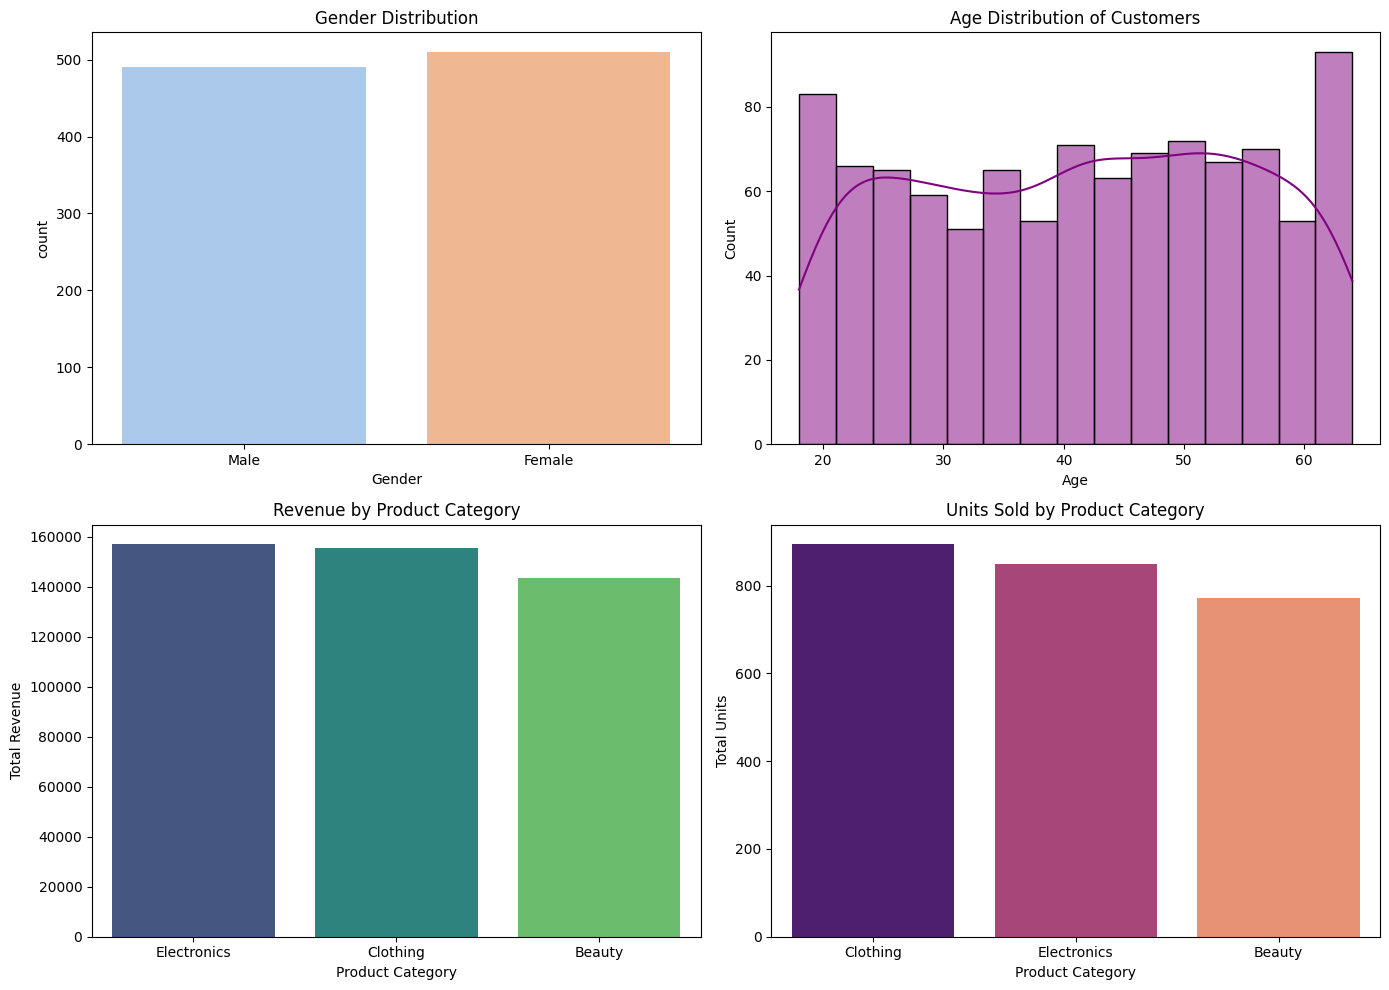

In [7]:
# Demographics and Product Analysis
plt.figure(figsize=(14, 10))

# 1. Gender Breakdown
plt.subplot(2, 2, 1)
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')

# 2. Age Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['Age'], bins=15, kde=True, color='purple')
plt.title('Age Distribution of Customers')

# 3. Revenue by Product Category
plt.subplot(2, 2, 3)
revenue_by_cat = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_cat.index, y=revenue_by_cat.values, palette='viridis')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')

# 4. Quantity Sold by Product Category
plt.subplot(2, 2, 4)
quantity_by_cat = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=quantity_by_cat.index, y=quantity_by_cat.values, palette='magma')
plt.title('Units Sold by Product Category')
plt.ylabel('Total Units')

plt.tight_layout()
plt.show()

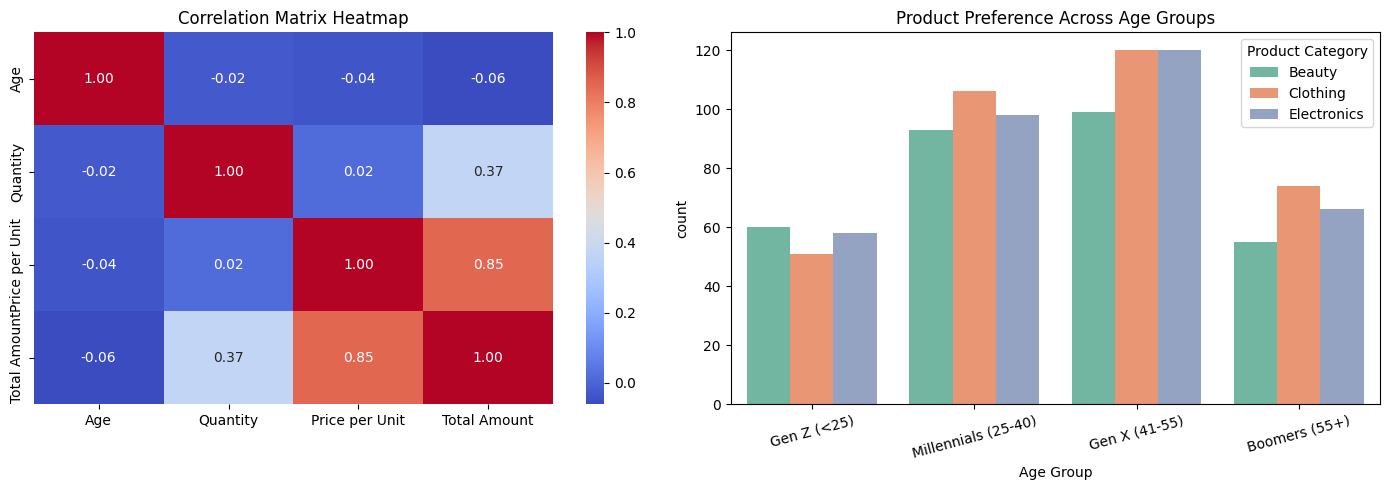

In [8]:
#Demographics and Product Analysis
plt.figure(figsize=(14, 5))

# Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')

# Additional Insight: Age Group vs Product Category Preference
age_bins = [0, 25, 40, 55, 100]
age_labels = ['Gen Z (<25)', 'Millennials (25-40)', 'Gen X (41-55)', 'Boomers (55+)']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

plt.subplot(1, 2, 2)
sns.countplot(x='Age Group', hue='Product Category', data=df, palette='Set2')
plt.title('Product Preference Across Age Groups')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

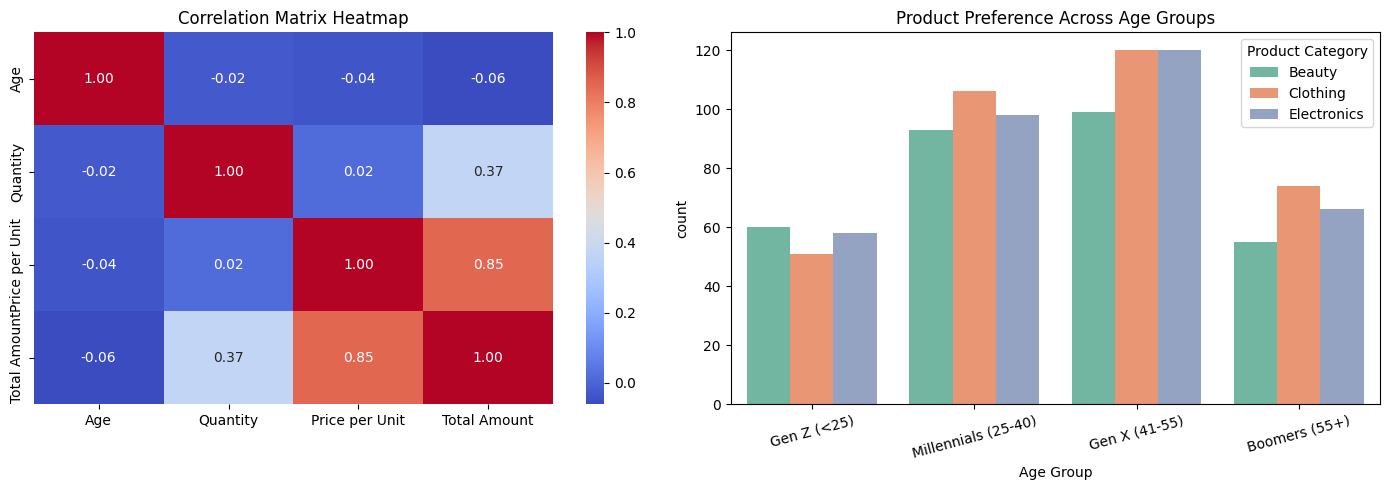

In [9]:
#Correlation Heatmap & Additional Insight
plt.figure(figsize=(14, 5))

# Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')

# Additional Insight: Age Group vs Product Category Preference
age_bins = [0, 25, 40, 55, 100]
age_labels = ['Gen Z (<25)', 'Millennials (25-40)', 'Gen X (41-55)', 'Boomers (55+)']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

plt.subplot(1, 2, 2)
sns.countplot(x='Age Group', hue='Product Category', data=df, palette='Set2')
plt.title('Product Preference Across Age Groups')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()